In [1]:
import os, sys
import subprocess
import json
import uproot3
import awkward as ak
import numpy as np
from coffea import processor, util, hist
import matplotlib.pyplot as plt
import pickle

/opt/conda/lib/python3.8/site-packages/coffea/util.py:154: FutureWarning: In coffea version v0.8.0 (target date: 31 Dec 2022), this will be an error.
(Set coffea.deprecations_as_errors = True to get a stack trace now.)
ImportError: coffea.hist is deprecated
  warnings.warn(message, FutureWarning)


In [2]:
ddbthr = 0.79
ddcthr = 0.15

In [3]:
year='2017'

# Check if pickle exists     
picklename = '2017_allyearsRun_2017/ttbar_templates.pkl'
if not os.path.isfile(picklename):
    print("You need to create the pickle")

In [4]:
# Read the histogram from the pickle file
templates = pickle.load(open(picklename,'rb')).sum('genflavor1','genflavor2').integrate('systematic','nominal').integrate('region','signal')
templates

<Hist (process,msd1,msd2,ddb1,ddc2) instance at 0x7f3e045b6a60>

<AxesSubplot:xlabel='Jet 2 $m_{sd}$', ylabel='Events'>

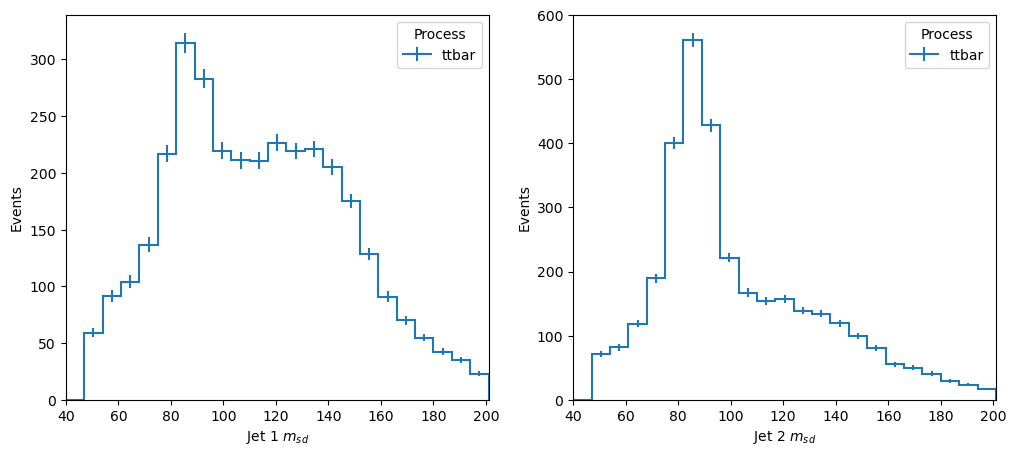

In [5]:
inclusive = templates.sum('ddb1','ddc2')

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
hist.plot1d(inclusive.sum('msd2'),overlay='process',ax=ax1)
hist.plot1d(inclusive.sum('msd1'),overlay='process',ax=ax2)

In [6]:
charmpass = templates.sum('msd2').integrate('ddc2',int_range=slice(ddcthr,1)).integrate('ddb1',int_range=slice(ddbthr,1))
charmfail = templates.sum('msd2').integrate('ddc2',int_range=slice(ddcthr,1)).integrate('ddb1',int_range=slice(0,ddbthr))

lightpass = templates.sum('msd2').integrate('ddc2',int_range=slice(0,ddcthr)).integrate('ddb1',int_range=slice(ddbthr,1))
lightfail = templates.sum('msd2').integrate('ddc2',int_range=slice(0,ddcthr)).integrate('ddb1',int_range=slice(0,ddbthr))

Text(0.5, 1.0, 'Light cat, DDB pass')

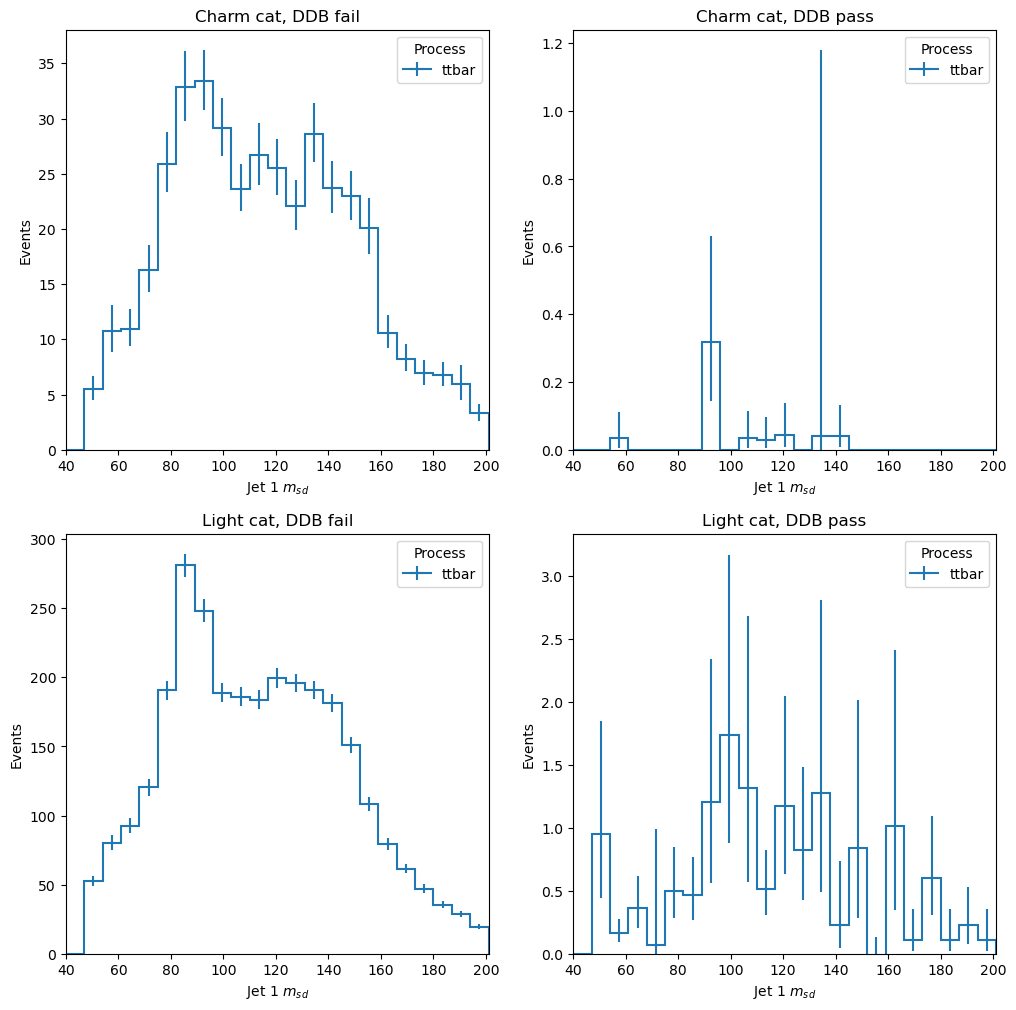

In [7]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(12,12))
hist.plot1d(charmfail,overlay='process',ax=ax1)
ax1.set_title('Charm cat, DDB fail')
hist.plot1d(charmpass,overlay='process',ax=ax2)
ax2.set_title('Charm cat, DDB pass')
hist.plot1d(lightfail,overlay='process',ax=ax3)
ax3.set_title('Light cat, DDB fail')
hist.plot1d(lightpass,overlay='process',ax=ax4)
ax4.set_title('Light cat, DDB pass')